In [1]:
import omicverse as ov
ov.plot_set()

2024-11-29 19:24:44.210521: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-29 19:24:44.223654: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-29 19:24:44.227631: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-29 19:24:44.237679: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-11-29 19:24:44.937803: W tensorflow/compiler/tf2


   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

Version: 1.6.9, Tutorials: https://omicverse.readthedocs.io/
Dependency error: (pydeseq2 0.4.11 (/mnt/home/zehuazeng/software/rsc/lib/python3.10/site-packages), Requirement.parse('pydeseq2<=0.4.0,>=0.3'))


In [2]:
adata=ov.read('data/GC_ST/GAS_GC_RAW_velo.h5ad')
adata

AnnData object with n_obs × n_vars = 93845 × 38606
    obs: 'sample_batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'patient', 'CancerType', 'mito_perc', 'cell_type_from_mulan_smoothing', 'CancerStage', 'gpt_celltype_0', 'Minor_celltype', 'cell_type_from_scMulan', 'log2umi', 'passing_ngenes', 'passing_mt', 'C_scANVI', 'gpt_celltype_2', 'best_celltype', 'cell_complexity', 'leiden', 'passing_nUMIs', 'cell_abbreviations', 'pct_counts_mt', 'detected_genes', 'smoothing_score', 'gpt_celltype_4', 'best_clusters', '_scvi_labels', 'celltype_gbi', 'n_genes', 'log2counts', 'doublet_score', 'gpt_celltype_1', 'celltype_gpt', 'Major_celltype', '_scvi_batch', 'nUMIs', 'gpt_celltype_3', 'predicted_doublet'
    var: 'gene_ids', 'feature_types', 'genome', 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    uns: 'best_celltype_colors'
    obsm: 'X_mde', 'X_mde_pca', 'X_mde_scANVI', 'X_mde_scVI', 'X_pca', 'X_scANVI', 'X_scMulan', 'X_scVI', 'scaled|original|X_pca'
    layers: 

In [3]:
adata.var.index.name='gene'
adata.obs.index.name='cell'

In [6]:
adata.X.max(),adata.layers['matrix'].max()

(34984.0, 33644.0)

In [7]:
adata.layers['count']=adata.X

In [8]:
import scanpy as sc
sc.pp.normalize_total(
    adata,
    target_sum=50*1e4,
    exclude_highly_expressed=True,
    max_fraction=0.2,
)
sc.pp.log1p(adata)

normalizing counts per cell. The following highly-expressed genes are not considered during normalization factor computation:
['GKN1', 'IGKC', 'IGKV4-1', 'IGKV1-5', 'IGKV1-6', 'IGKV3-7', 'IGKV1-8', 'IGKV1-9', 'IGKV3-11', 'IGKV1-12', 'IGKV3-15', 'IGKV1-16', 'IGKV1-17', 'IGKV3-20', 'IGKV6-21', 'IGKV2-24', 'IGKV1-27', 'IGKV2-28', 'IGKV2-29', 'IGKV2-30', 'IGKV1-33', 'IGKV1-39', 'IGKV2D-40', 'IGKV1D-39', 'IGKV1D-33', 'IGKV2D-30', 'IGKV2D-29', 'IGKV2D-28', 'IGKV2D-24', 'IGKV6D-21', 'IGKV3D-20', 'IGKV3D-15', 'IGKV1D-13', 'IGKV1OR2-108', 'GHRL', 'SST', 'JCHAIN', 'MLN', 'PGC', 'DEFA6', 'DEFA5', 'LIPF', 'HBB', 'PGA3', 'FTH1', 'MALAT1', 'IGHA2', 'IGHG4', 'IGHA1', 'IGHG1', 'IGHG3', 'IGHM', 'IGHV6-1', 'IGHV1-2', 'IGHV1-3', 'IGHV7-4-1', 'IGHV2-5', 'IGHV3-7', 'IGHV5-10-1', 'IGHV3-11', 'IGHV3-13', 'IGHV3-15', 'IGHV1-18', 'IGHV3-21', 'IGHV3-23', 'IGHV1-24', 'IGHV2-26', 'IGHV3-30', 'IGHV3-33', 'IGHV4-34', 'IGHV4-39', 'IGHV3-43', 'IGHV1-46', 'IGHV3-48', 'IGHV3-49', 'IGHV5-51', 'IGHV3-53', 'IGHV1-58', 'IG

In [9]:
adata=adata[adata.obs['CancerStage'].isin(['No','T1'])]

In [10]:
condition_key = 'CancerStage'
# We construct 20 gene expression modules using the raw cell count.
ov.externel.flowsig.pp.construct_gems_using_pyliger(adata,
                                n_gems = 20,
                                layer_key = 'count',
                                condition_key = condition_key)

Removing 7799 genes not expressing in No.
Removing 8994 genes not expressing in T1.


100%|██████████| 30/30 [31:02<00:00, 62.09s/it]


In [11]:
adata.write('data/GC_RNA/GAS_GC_RAW_pyliger.h5ad')

In [4]:
adata=ov.read('data/GC_RNA/GAS_GC_RAW_pyliger.h5ad')

In [11]:
condition_key = 'CancerStage'

In [5]:
cpdb_res_gas=ov.utils.load('result/cpdb_results_gas.pkl')
cpdb_res_gas.keys()

dict_keys(['deconvoluted', 'deconvoluted_percents', 'means', 'relevant_interactions', 'significant_means', 'CellSign_active_interactions', 'CellSign_active_interactions_deconvoluted', 'interaction_scores'])

In [6]:
cpdb_res_gc=ov.utils.load('result/cpdb_results_gc.pkl')
cpdb_res_gc.keys()

dict_keys(['deconvoluted', 'deconvoluted_percents', 'means', 'relevant_interactions', 'significant_means', 'CellSign_active_interactions', 'CellSign_active_interactions_deconvoluted', 'interaction_scores'])

In [7]:
# Make sure your keys for these align with their condition labels
import pandas as pd
cpdb_results = {}
cpdb_active_tfs = {}
cpdb_results['gas']=cpdb_res_gas['significant_means']
cpdb_active_tfs['gas']=cpdb_res_gas['CellSign_active_interactions_deconvoluted']

cpdb_results['gc']=cpdb_res_gc['significant_means']
cpdb_active_tfs['gc']=cpdb_res_gc['CellSign_active_interactions_deconvoluted']


In [8]:
# Subset for only secreted ligand-receptor interactions
for cond in cpdb_results:
    sig_means = cpdb_results[cond]
    cpdb_results[cond] = sig_means[(sig_means['secreted'] == True)&(sig_means['directionality'] == 'Ligand-Receptor')]
    
cellphonedb_output_key = 'cellphonedb_output'
adata.uns[cellphonedb_output_key] = cpdb_results
cellphonedb_tfs_key = 'cellphonedb_active_tfs'
adata.uns[cellphonedb_tfs_key] = cpdb_active_tfs

In [9]:
# We first construct the potential cellular flows from the cellchat output
ov.externel.flowsig.pp.construct_flows_from_cellphonedb(adata,
                                cellphonedb_output_key,
                                cellphonedb_tfs_key,
                                gem_expr_key = 'X_gem',
                                scale_gem_expr = True,
                                model_organism = 'human',
                                flowsig_network_key = 'flowsig_network_cpdb',
                                flowsig_expr_key = 'X_flow_cpdb')

# Delete teh cellphonedb output otherwise there will be trouble when saving the anndata objct
del adata.uns[cellphonedb_output_key]
del adata.uns[cellphonedb_tfs_key]

In [7]:
condition_key = 'CancerStage'

In [ ]:
# Then we subset for "differentially flowing" variables
ov.externel.flowsig.pp.determine_informative_variables(adata,  
                                    flowsig_expr_key = 'X_flow_cpdb',
                                    flowsig_network_key = 'flowsig_network_cpdb',
                                    spatial = False,
                                    condition_key = condition_key,
                                    control_key =  'No',
                                    qval_threshold = 0.05,
                                    logfc_threshold = 1.5)

# Now we are ready to learn the network
ov.externel.flowsig.tl.learn_intercellular_flows(adata,
                        condition_key = condition_key,
                        control_key = 'No', 
                        flowsig_key = 'flowsig_network_cpdb',
                        flow_expr_key = 'X_flow_cpdb',
                        use_spatial = False,
                        n_jobs = 4,
                        n_bootstraps = 500)



ranking genes


... storing 'Type' as categorical
... storing 'Downstream_TF' as categorical


    finished: added to `.uns['CancerStage']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)
ranking genes


... storing 'Type' as categorical
... storing 'Downstream_TF' as categorical


    finished: added to `.uns['CancerStage']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)
starting computations on 4 cores


...

2024-11-28 17:22:51.432307: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-28 17:22:51.463777: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-28 17:22:51.473310: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-28 17:22:53.172502: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT



   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

Version: 1.6.9, Tutorials: https://omicverse.readthedocs.io/


2024-11-28 17:58:04.558670: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-28 17:58:04.590433: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-28 17:58:04.600058: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-28 17:58:06.364412: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT



   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

Version: 1.6.9, Tutorials: https://omicverse.readthedocs.io/


2024-11-28 18:07:25.898868: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-11-28 18:07:25.929956: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-11-28 18:07:25.939404: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-28 18:07:27.635248: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [40]:
adata.write('data/GC_RNA/gas_gc_flowsig.h5ad',compression='gzip')

In [60]:
adata=ov.read('data/GC_RNA/gas_gc_flowsig.h5ad',compression='gzip')

In [41]:
adata.uns[flowsig_network_key]['flow_var_info'].index=[f"{i}:{j}" for i,j in zip(adata.uns[flowsig_network_key]['flow_var_info'].index.tolist(),
                                            adata.uns[flowsig_network_key]['flow_var_info']['Type'].tolist())]

In [4]:
import anndata as ad
ad.utils.make_index_unique

<function anndata.utils.make_index_unique(index: 'pd.Index', join: 'str' = '-')>

In [6]:
flowsig_network_key='flowsig_network_cpdb'
adata.uns[flowsig_network_key]['flow_var_info'].index=ad.utils.make_index_unique(adata.uns[flowsig_network_key]['flow_var_info'].index)

In [65]:
for i in adata.var_names:
    if i=='AGRN':
        print(i)

AGRN


In [7]:
# Now we do post-learning validation to reorient the network and remove low-quality edges.
# This part is key for reducing false positives
ov.externel.flowsig.tl.apply_biological_flow(adata,
                        flowsig_network_key = 'flowsig_network_cpdb',
                        adjacency_key = 'adjacency',
                        validated_key = 'validated')

edge_threshold = 0.7

ov.externel.flowsig.tl.filter_low_confidence_edges(adata,
                                edge_threshold = edge_threshold,
                                flowsig_network_key = 'flowsig_network_cpdb',
                                adjacency_key = 'adjacency_validated',
                                filtered_key = 'filtered')

[[0.    0.    0.    ... 0.018 0.04  0.02 ]
 [0.    0.    0.    ... 0.    0.004 0.03 ]
 [0.    0.    0.    ... 0.07  0.016 0.006]
 ...
 [0.042 0.002 0.244 ... 0.    0.546 0.554]
 [0.068 0.078 0.094 ... 0.44  0.    0.43 ]
 [0.044 0.256 0.004 ... 0.446 0.444 0.   ]]
[[0.    0.    0.    ... 0.    0.    0.   ]
 [0.    0.    0.    ... 0.    0.    0.   ]
 [0.    0.    0.    ... 0.    0.    0.   ]
 ...
 [0.    0.    0.    ... 0.    0.546 0.554]
 [0.    0.    0.    ... 0.44  0.    0.43 ]
 [0.    0.    0.    ... 0.446 0.444 0.   ]]


In [67]:
adata

AnnData object with n_obs × n_vars = 22357 × 38606
    obs: 'sample_batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'patient', 'CancerType', 'mito_perc', 'cell_type_from_mulan_smoothing', 'CancerStage', 'gpt_celltype_0', 'Minor_celltype', 'cell_type_from_scMulan', 'log2umi', 'passing_ngenes', 'passing_mt', 'C_scANVI', 'gpt_celltype_2', 'best_celltype', 'cell_complexity', 'leiden', 'passing_nUMIs', 'cell_abbreviations', 'pct_counts_mt', 'detected_genes', 'smoothing_score', 'gpt_celltype_4', 'best_clusters', '_scvi_labels', 'celltype_gbi', 'n_genes', 'log2counts', 'doublet_score', 'gpt_celltype_1', 'celltype_gpt', 'Major_celltype', '_scvi_batch', 'nUMIs', 'gpt_celltype_3', 'predicted_doublet'
    var: 'gene_ids', 'feature_types', 'genome', 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    uns: 'best_celltype_colors', 'flowsig_network_cpdb', 'flowsig_network_cpdb_orig', 'log1p', 'pyliger_info'
    obsm: 'X_flow_cpdb', 'X_flow_cpdb_orig', 'X_gem', 'X_mde', '

ranking genes


... storing 'Type' as categorical
... storing 'Downstream_TF' as categorical


    finished: added to `.uns['CancerStage']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:00)


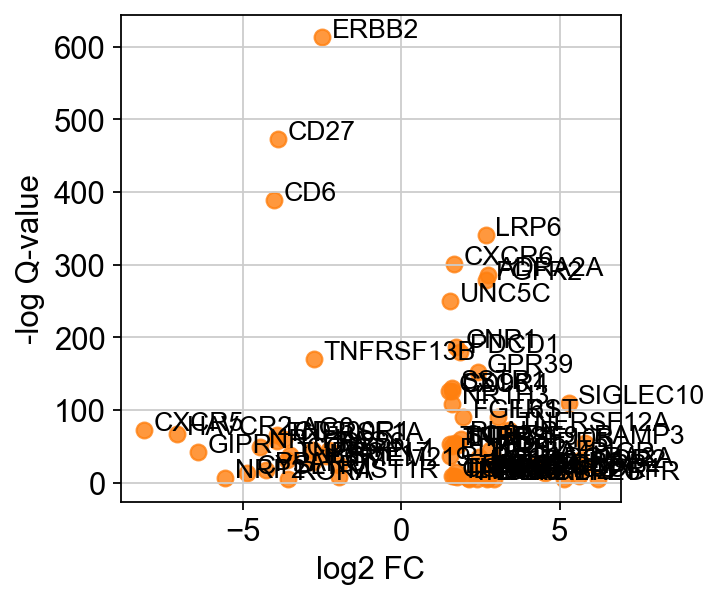

In [68]:
#fig, ax = plt.subplots(figsize=(6, 4))
ov.externel.flowsig.pl._plotting.plot_differentially_flowing_signals(adata,
                                        condition_key = condition_key,
                                        pert_key = 'No',
                                        var_type = 'inflow',
                                        flowsig_expr_key = 'X_flow_cpdb',
                                        flowsig_network_key = 'flowsig_network_cpdb',
                                        qval_threshold = 0.05,
                                        logfc_threshold = 0.5,
                                        label_lowqval = True,
                                        #ax=ax
                                        )
#plt.show()

In [16]:
adata.write('data/GC_RNA/gas_gc_flowsig.h5ad',compression='gzip')

In [2]:
adata=ov.read('data/GC_RNA/gas_gc_flowsig.h5ad',compression='gzip')
adata

AnnData object with n_obs × n_vars = 22357 × 38606
    obs: 'sample_batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'patient', 'CancerType', 'mito_perc', 'cell_type_from_mulan_smoothing', 'CancerStage', 'gpt_celltype_0', 'Minor_celltype', 'cell_type_from_scMulan', 'log2umi', 'passing_ngenes', 'passing_mt', 'C_scANVI', 'gpt_celltype_2', 'best_celltype', 'cell_complexity', 'leiden', 'passing_nUMIs', 'cell_abbreviations', 'pct_counts_mt', 'detected_genes', 'smoothing_score', 'gpt_celltype_4', 'best_clusters', '_scvi_labels', 'celltype_gbi', 'n_genes', 'log2counts', 'doublet_score', 'gpt_celltype_1', 'celltype_gpt', 'Major_celltype', '_scvi_batch', 'nUMIs', 'gpt_celltype_3', 'predicted_doublet'
    var: 'gene_ids', 'feature_types', 'genome', 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    uns: 'best_celltype_colors', 'flowsig_network_cpdb', 'flowsig_network_cpdb_orig', 'log1p', 'pyliger_info'
    obsm: 'X_flow_cpdb', 'X_flow_cpdb_orig', 'X_gem', 'X_mde', '

In [8]:
flow_network = ov.externel.flowsig.tl.construct_intercellular_flow_network(adata,
                                                        flowsig_network_key = 'flowsig_network_cpdb',
                                                        adjacency_key = 'adjacency_validated_filtered')

In [9]:
gem_li=[i for i in flow_network.nodes if 'GEM' in i]
receptor_li=[i for i,j in flow_network.edges if ('GEM' in j)and('GEM' not in i)]
sender_li=[j for i,j in flow_network.edges if ('GEM' in i)and('GEM' not in j)]
#gene_li=[i for i in flow_network.nodes if 'GEM' not in i]
G_type_dict=dict(zip(gem_li+receptor_li+sender_li,
        ['GEM' for i in range(len(gem_li))]+\
                     ['Receptor' for i in range(len(receptor_li))]+\
                    ['Sender' for i in range(len(sender_li))]))


In [90]:
G_type_dict

{'GEM-9': 'GEM',
 'GEM-11': 'GEM',
 'GEM-15': 'GEM',
 'GEM-6': 'GEM',
 'GEM-14': 'GEM',
 'GEM-5': 'GEM',
 'GEM-1': 'GEM',
 'GEM-12': 'GEM',
 'GEM-7': 'GEM',
 'GEM-18': 'GEM',
 'GEM-13': 'GEM',
 'GEM-20': 'GEM',
 'GEM-19': 'GEM',
 'GEM-3': 'GEM',
 'GEM-16': 'GEM',
 'GEM-10': 'GEM',
 'GEM-2': 'GEM',
 'GEM-17': 'GEM',
 'GEM-4': 'GEM',
 'GEM-8': 'GEM',
 'TNFRSF12A': 'Receptor',
 'TNFRSF9': 'Receptor',
 'LRP6': 'Receptor',
 'AXL': 'Receptor',
 'IGFLR1': 'Receptor',
 'NR1H3': 'Receptor',
 'ERBB3': 'Receptor',
 'BSG': 'Receptor',
 'PDCD1': 'Receptor',
 'NR1H2': 'Receptor',
 'PIGR': 'Receptor',
 'FGFR1': 'Receptor',
 'ADORA2A': 'Receptor',
 'CD6': 'Receptor',
 'FGFR2': 'Receptor',
 'SIGLEC10': 'Receptor',
 'IL1RAP': 'Receptor',
 'CNR1': 'Receptor',
 'CD27': 'Receptor',
 'EPHB6': 'Receptor',
 'CD96': 'Receptor',
 'PTGDR': 'Receptor',
 'ADRA2A': 'Receptor',
 'CXCR6': 'Receptor',
 'ADGRE5': 'Receptor',
 'DPP4': 'Receptor',
 'CD226': 'Receptor',
 'CXCR4': 'Receptor',
 'RAMP3': 'Receptor',
 'EDNRB'

In [99]:
gem_li=[i for i in flow_network.nodes if 'GEM' in i]
receptor_li=[i for i,j in flow_network.edges if ('GEM' in j)and('GEM' not in i)]
sender_li=[j for i,j in flow_network.edges if ('GEM' in i)and('GEM' not in j)]
#gene_li=[i for i in flow_network.nodes if 'GEM' not in i]
G_color_dict=dict(zip(gem_li+receptor_li+sender_li,
        [ov.pl.sc_color[i] for i in range(len(gem_li))]+\
                     ['#c2c2c2'  for i in range(len(receptor_li))]+\
                    ['#a51616' for i in range(len(sender_li))]))


In [112]:
import networkx as nx
#G = nx.Graph([(0, 1), (1, 2), (1, 3), (3, 4)])
layers = {"layer1": list(set(sender_li)),  "layer3": list(set(receptor_li)),"layer2": list(set(gem_li)),}
pos = nx.multipartite_layout(flow_network, subset_key=layers,align='horizontal',scale=2)

In [1]:
import networkx as nx
nx.__version__

'3.3'

In [114]:
#fig, ax = plt.subplots(figsize=(8,8)) 
sub_G=flow_network.subgraph(sender_li+receptor_li+['GEM-5','GEM-11','GEM-13','GEM-16']).copy()
# 获取所有节点和边
all_nodes = set(sub_G.nodes())
all_edges = sub_G.edges()
# 找到没有连接边的节点
nodes_with_edges = set()
for edge in all_edges:
    nodes_with_edges.update(edge)
    
nodes_without_edges = all_nodes - nodes_with_edges

# 从图中删除这些节点
sub_G.remove_nodes_from(nodes_without_edges)

[Text(-0.03125, -0.00041946308724832214, 'GEM-5'), Text(-0.34375, -0.00041946308724832214, 'GEM-11'), Text(-0.40625, -0.00041946308724832214, 'GEM-13'), Text(0.21875, -0.00041946308724832214, 'GEM-16'), Text(-0.21875, -0.06291946308724833, 'GAS6'), Text(0.3125, 0.06208053691275168, 'TNFRSF9'), Text(-0.875, 0.06208053691275168, 'LRP6'), Text(-0.75, 0.06208053691275168, 'ERBB3'), Text(-1.875, 0.06208053691275168, 'BSG'), Text(-0.5625, 0.06208053691275168, 'ADORA2A'), Text(0.0, 0.06208053691275168, 'FGFR2'), Text(-1.9375, 0.06208053691275168, 'CD27'), Text(0.9375, 0.06208053691275168, 'CD96'), Text(1.625, 0.06208053691275168, 'PTGDR'), Text(1.0625, 0.06208053691275168, 'ADRA2A'), Text(-0.4375, 0.06208053691275168, 'ADGRE5'), Text(-0.0625, 0.06208053691275168, 'CXCR4'), Text(-1.0625, 0.06208053691275168, 'UNC5C'), Text(-1.96875, -0.06291946308724833, 'LAMC1'), Text(-0.90625, -0.06291946308724833, 'SEMA3C')]


(<Figure size 640x320 with 1 Axes>, <AxesSubplot: >)

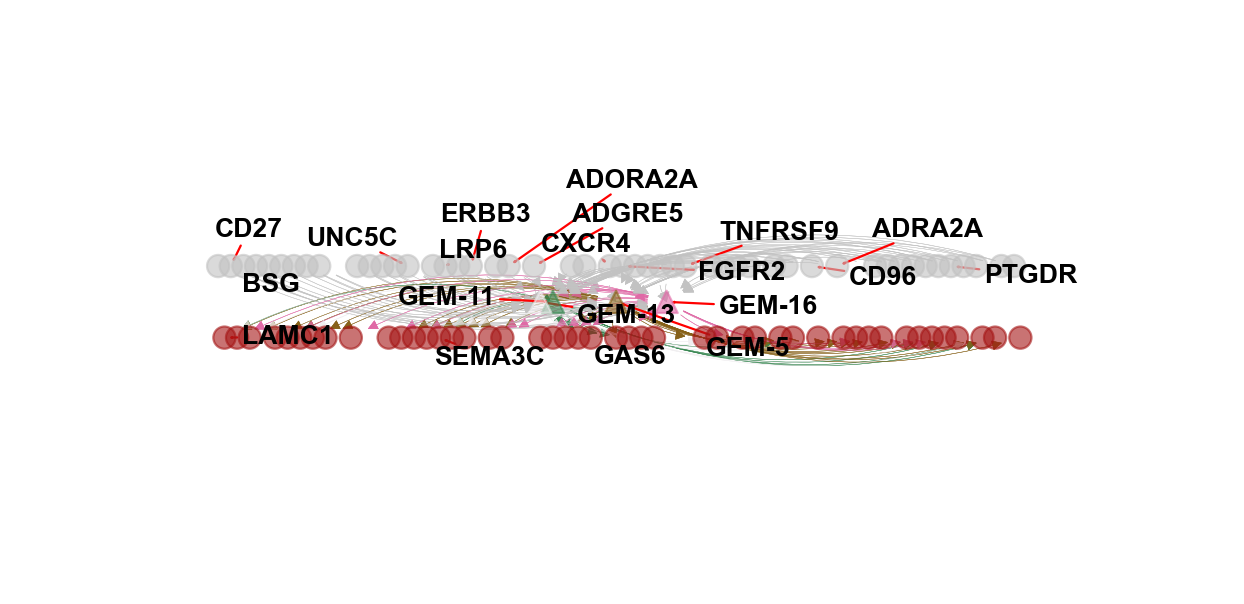

In [115]:
ov.pl.plot_curve_network(sub_G,
                     G_type_dict=G_type_dict,
                     G_color_dict=G_color_dict,
                      pos_type=pos,
                      figsize=(8,4),
                     curve_awarg={'eps':2},
                      node_shape={'GEM':'^','Sender':'o','Receptor':'o'}
                     )
#plt.box(False)

In [12]:
import scanpy as sc
flowsig_expr_key='X_gem'
X_flow = adata.obsm[flowsig_expr_key]
adata_subset = sc.AnnData(X=X_flow)
adata_subset.obs = adata.obs
adata_subset.var.index =[f'GEM-{i}' for i in range(1,len(adata_subset.var)+1)]


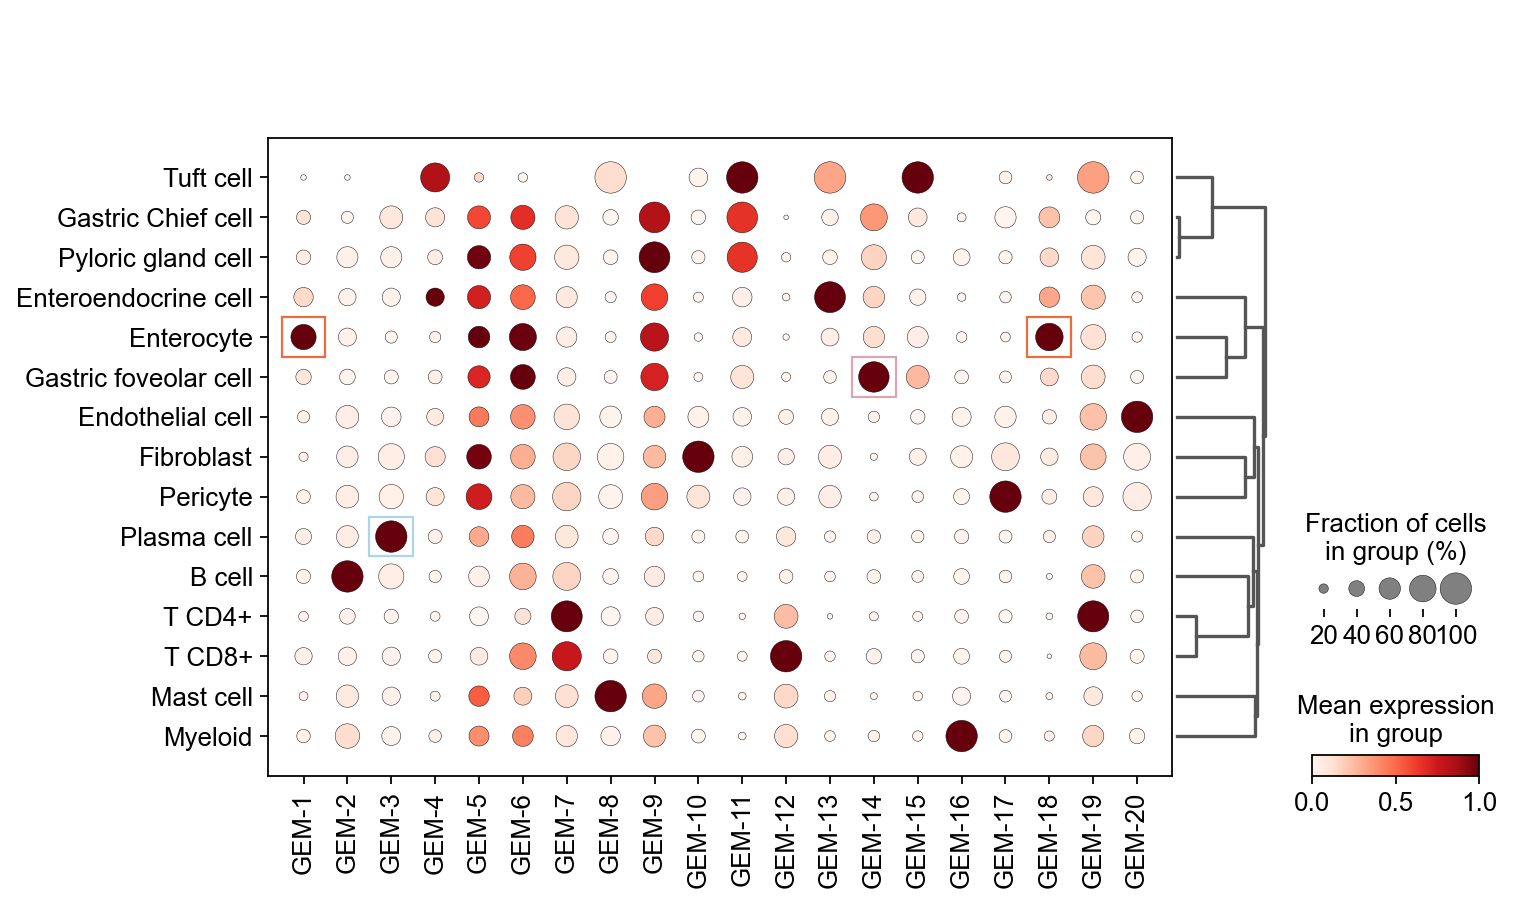

In [20]:
import matplotlib.pyplot as plt
ax=sc.pl.dotplot(adata_subset, adata_subset.var.index, groupby='best_celltype', 
              dendrogram=True,standard_scale='var',cmap='Reds',show=False)
color_dict=dict(zip(adata.obs['best_celltype'].cat.categories,adata.uns['best_celltype_colors']))

ax['mainplot_ax'].add_patch(plt.Rectangle((2,9),1,1,fill=False,color=color_dict['Plasma cell'],lw=1))
ax['mainplot_ax'].add_patch(plt.Rectangle((0,4),1,1,fill=False,color=color_dict['Enterocyte'],lw=1))
ax['mainplot_ax'].add_patch(plt.Rectangle((17,4),1,1,fill=False,color=color_dict['Enterocyte'],lw=1))
ax['mainplot_ax'].add_patch(plt.Rectangle((13,5),1,1,fill=False,color=color_dict['Gastric foveolar cell'],lw=1))
plt.savefig(f'figures/signal/gc_flowsig_dot.png',dpi=300,bbox_inches='tight')

In [30]:
goal_gem='GEM-18'
gem_tf=ov.externel.flowsig.ul.get_top_gem_genes(adata=adata,
                                            gems=[goal_gem],
                                         n_genes=10,
                                         gene_type='tf',
                                        method = 'pyliger',
                                        )
gem_tf

,Gene,GEM,Weight
0,EDN1,GEM-18,99.275817
1,CDX2,GEM-18,89.105607
2,OVOL1,GEM-18,86.317541
3,ETV4,GEM-18,84.021189
4,CKMT1B,GEM-18,80.071319
5,BARX2,GEM-18,78.778668
6,FOSL1,GEM-18,78.127011
7,GTF2IRD1,GEM-18,76.910940
8,CDX1,GEM-18,74.359788
9,EHF,GEM-18,70.802914


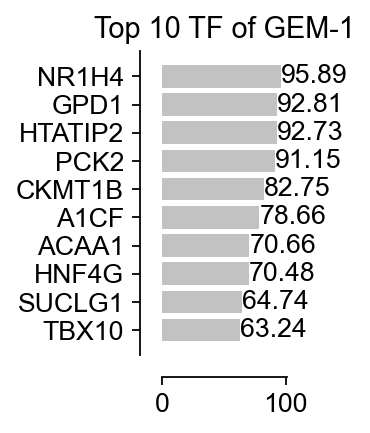

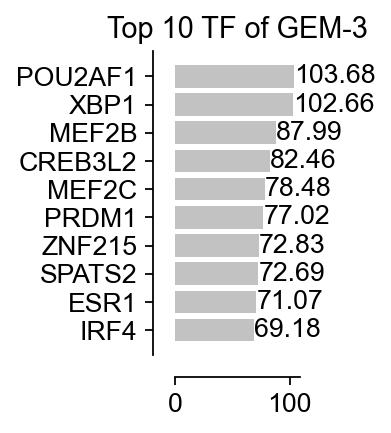

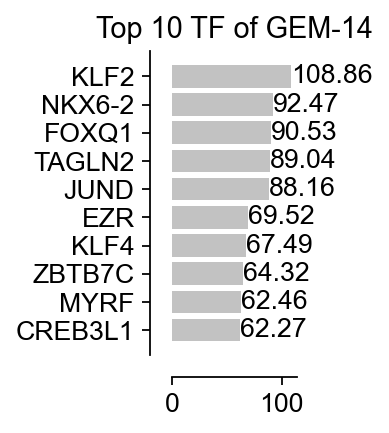

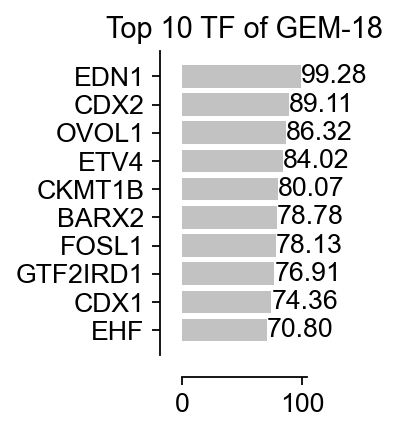

In [173]:
for goal_gem in ['GEM-1','GEM-3','GEM-14','GEM-18']:

   # goal_gem='GEM-18'
    gem_tf=ov.externel.flowsig.ul.get_top_gem_genes(adata=adata,
                                                gems=[goal_gem],
                                             n_genes=10,
                                             gene_type='tf',
                                            method = 'pyliger',
                                            )
    
    fig, ax = plt.subplots(figsize=(1,2.5))
    ax.barh(y=gem_tf['Gene'],
         width=gem_tf['Weight'],
           color='#c2c2c2')
    ax.invert_yaxis()
    for idx,i in enumerate(list(gem_tf['Gene'].index)):
        ax.text(gem_tf.loc[i,'Weight']+0.005,idx,'{:.2f}'.format(gem_tf.loc[i,'Weight']),
                fontsize=12,verticalalignment='center')
    plt.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_position(('outward', 10))
    ax.spines['bottom'].set_position(('outward', 10))
    
    plt.yticks(fontsize=12)
    plt.xticks(fontsize=12)
    plt.title(f'Top 10 TF of {goal_gem}' ,fontsize=13)
    plt.savefig(f'figures/signal/gc_gem_top10tf_{goal_gem}.png',dpi=300,bbox_inches='tight')


## DEG

### inflow

In [32]:
adata_sub=ov.externel.flowsig.pl._plotting.subset_for_flow_type(adata,
                                                     var_type = 'all',
                                                     flowsig_expr_key = 'X_flow_cpdb',
                                                flowsig_network_key = 'flowsig_network_cpdb',)
adata_sub

AnnData object with n_obs × n_vars = 22357 × 172
    obs: 'sample_batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'patient', 'CancerType', 'mito_perc', 'cell_type_from_mulan_smoothing', 'CancerStage', 'gpt_celltype_0', 'Minor_celltype', 'cell_type_from_scMulan', 'log2umi', 'passing_ngenes', 'passing_mt', 'C_scANVI', 'gpt_celltype_2', 'best_celltype', 'cell_complexity', 'leiden', 'passing_nUMIs', 'cell_abbreviations', 'pct_counts_mt', 'detected_genes', 'smoothing_score', 'gpt_celltype_4', 'best_clusters', '_scvi_labels', 'celltype_gbi', 'n_genes', 'log2counts', 'doublet_score', 'gpt_celltype_1', 'celltype_gpt', 'Major_celltype', '_scvi_batch', 'nUMIs', 'gpt_celltype_3', 'predicted_doublet'
    var: 'Type', 'Downstream_TF', 'Interaction'

In [33]:
adata_sub=adata_sub[:,adata_sub.var['Type'].isin(['inflow'])]
adata_sub

View of AnnData object with n_obs × n_vars = 22357 × 76
    obs: 'sample_batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'patient', 'CancerType', 'mito_perc', 'cell_type_from_mulan_smoothing', 'CancerStage', 'gpt_celltype_0', 'Minor_celltype', 'cell_type_from_scMulan', 'log2umi', 'passing_ngenes', 'passing_mt', 'C_scANVI', 'gpt_celltype_2', 'best_celltype', 'cell_complexity', 'leiden', 'passing_nUMIs', 'cell_abbreviations', 'pct_counts_mt', 'detected_genes', 'smoothing_score', 'gpt_celltype_4', 'best_clusters', '_scvi_labels', 'celltype_gbi', 'n_genes', 'log2counts', 'doublet_score', 'gpt_celltype_1', 'celltype_gpt', 'Major_celltype', '_scvi_batch', 'nUMIs', 'gpt_celltype_3', 'predicted_doublet'
    var: 'Type', 'Downstream_TF', 'Interaction'

In [34]:
adata_sub.layers['normalized']=adata_sub.X.copy()

In [35]:
def deg_clusters(adata,cluster_type,group_type,
                treatmentgroup,controlgroup,layer='normalized'):
    from tqdm import tqdm
    deg_results_dict={}
    adata.obs[cluster_type]=adata.obs[cluster_type].astype('category')
    for cluster in tqdm(adata.obs[cluster_type].cat.categories):
        adata_sub=adata[adata.obs[cluster_type]==cluster]
        test_adata=adata_sub
        dds=ov.bulk.pyDEG(test_adata.to_df(layer=layer).T)
        treatment_groups=test_adata.obs[test_adata.obs[group_type]==treatmentgroup].index.tolist()
        if len(treatment_groups)<=1:
            continue
        control_groups=test_adata.obs[test_adata.obs[group_type]==controlgroup].index.tolist()
        if len(control_groups)<=1:
            continue
        dds.result=dds.deg_analysis(treatment_groups,control_groups,method='ttest')
        dds.result=dds.result.loc[dds.result['BaseMean']>0.5]
        # -1 means automatically calculates
        dds.foldchange_set(fc_threshold=0.5,
                           pval_threshold=0.05,
                           logp_max=10)
        deg_results_dict[cluster]=dds.result
    adata.uns['deg_clusters_dict']=deg_results_dict
    return deg_results_dict
deg_results_dict_inflow=deg_clusters(adata=adata_sub,cluster_type='best_celltype',group_type='CancerStage',
                treatmentgroup='T1',controlgroup='No',layer='normalized')

 47%|████▋     | 7/15 [00:00<00:00, 30.29it/s]

... Fold change threshold: 0.5
... Fold change threshold: 0.5
... Fold change threshold: 0.5
... Fold change threshold: 0.5
... Fold change threshold: 0.5
... Fold change threshold: 0.5
... Fold change threshold: 0.5
... Fold change threshold: 0.5
... Fold change threshold: 0.5
... Fold change threshold: 0.5
... Fold change threshold: 0.5
... Fold change threshold: 0.5
... Fold change threshold: 0.5


100%|██████████| 15/15 [00:00<00:00, 39.52it/s]

... Fold change threshold: 0.5


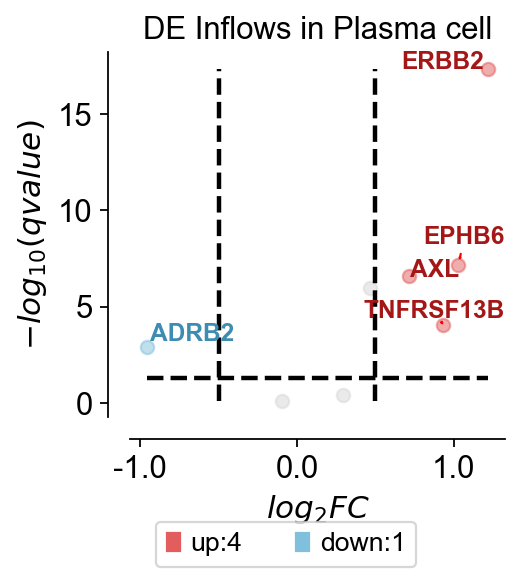

In [38]:
deg_cluster='Plasma cell'
ov.pl.volcano(deg_results_dict_inflow[deg_cluster],pval_name='qvalue',fc_name='log2FC',
                     pval_threshold=0.05,fc_max=0.5,fc_min=-0.5,
                      pval_max=100,FC_max=3,
                    figsize=(3,3),title=f'DE Inflows in {deg_cluster}',titlefont={'weight':'normal','size':14,},
                     up_color='#e25d5d',down_color=ov.pl.blue_color[2],normal_color='#d7d7d7',
                     up_fontcolor='#a51616',down_fontcolor=ov.pl.blue_color[3],normal_fontcolor='#d7d7d7',
                     legend_bbox=(0.8, -0.25),legend_ncol=2,legend_fontsize=12,
                     #plot_genes=['CMKLR1', 'ARHGEF10L', 'PRG4', 'OLR1', 'CRTAC1'],
                    plot_genes_num=10,plot_genes_fontsize=11,
                     ticks_fontsize=12,)
plt.savefig(f'figures/signal/gc_deg_inflow_{deg_cluster}.png',dpi=300,bbox_inches='tight')
#plt.savefig(f'pdf/signal/ra3a_deg_inflow_{deg_cluster}.pdf',dpi=300,bbox_inches='tight')


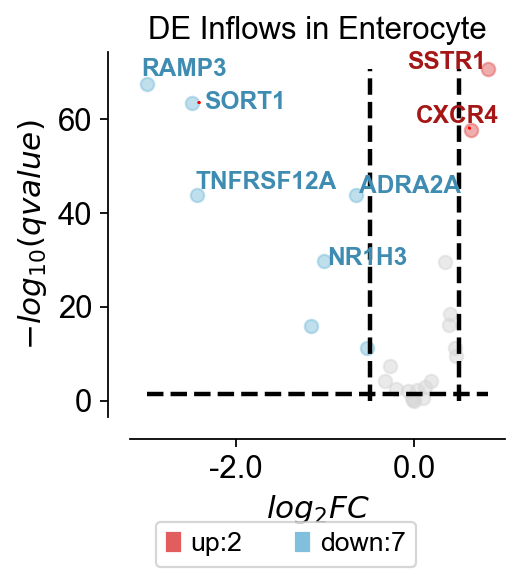

In [40]:
deg_cluster='Enterocyte'
ov.pl.volcano(deg_results_dict_inflow[deg_cluster],pval_name='qvalue',fc_name='log2FC',
                     pval_threshold=0.05,fc_max=0.5,fc_min=-0.5,
                      pval_max=100,FC_max=3,
                    figsize=(3,3),title=f'DE Inflows in {deg_cluster}',titlefont={'weight':'normal','size':14,},
                     up_color='#e25d5d',down_color=ov.pl.blue_color[2],normal_color='#d7d7d7',
                     up_fontcolor='#a51616',down_fontcolor=ov.pl.blue_color[3],normal_fontcolor='#d7d7d7',
                     legend_bbox=(0.8, -0.25),legend_ncol=2,legend_fontsize=12,
                     #plot_genes=['CMKLR1', 'ARHGEF10L', 'PRG4', 'OLR1', 'CRTAC1'],
                    plot_genes_num=10,plot_genes_fontsize=11,
                     ticks_fontsize=12,)
plt.savefig(f'figures/signal/gc_deg_inflow_{deg_cluster}.png',dpi=300,bbox_inches='tight')


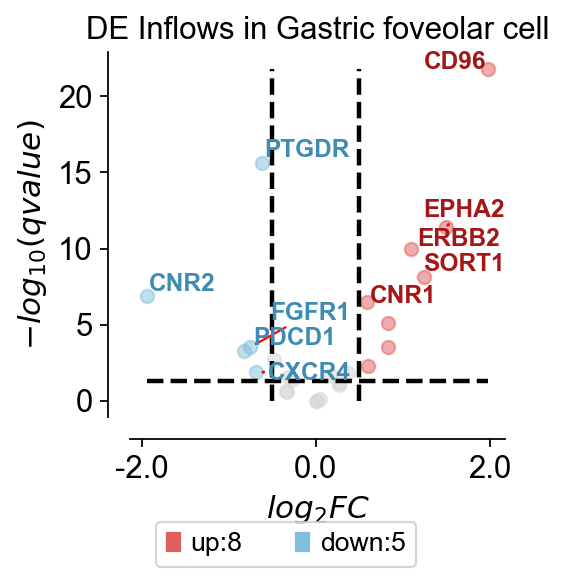

In [66]:
deg_cluster='Gastric foveolar cell'
ov.pl.volcano(deg_results_dict_inflow[deg_cluster],pval_name='qvalue',fc_name='log2FC',
                     pval_threshold=0.05,fc_max=0.5,fc_min=-0.5,
                      pval_max=100,FC_max=3,
                    figsize=(3,3),title=f'DE Inflows in {deg_cluster}',titlefont={'weight':'normal','size':14,},
                     up_color='#e25d5d',down_color=ov.pl.blue_color[2],normal_color='#d7d7d7',
                     up_fontcolor='#a51616',down_fontcolor=ov.pl.blue_color[3],normal_fontcolor='#d7d7d7',
                     legend_bbox=(0.8, -0.25),legend_ncol=2,legend_fontsize=12,
                     #plot_genes=['CMKLR1', 'ARHGEF10L', 'PRG4', 'OLR1', 'CRTAC1'],
                    plot_genes_num=10,plot_genes_fontsize=11,
                     ticks_fontsize=12,)
plt.savefig(f'figures/signal/gc_deg_inflow_{deg_cluster}.png',dpi=300,bbox_inches='tight')


In [41]:
adata_sub.obsm=adata.obsm.copy()

<AxesSubplot: title={'center': 'Group'}, xlabel='X_mde_scVI1', ylabel='X_mde_scVI2'>

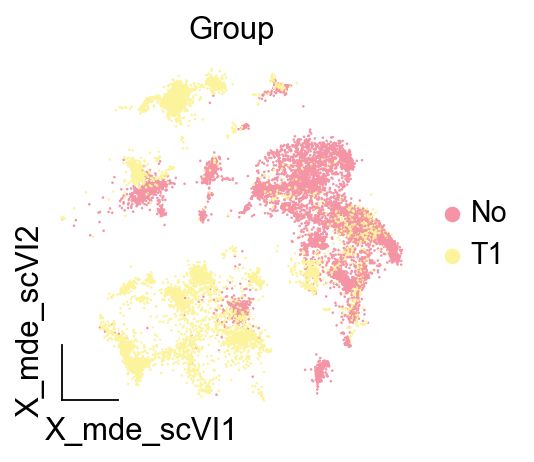

In [44]:
fb=ov.pl.ForbiddenCity()
fig, ax = plt.subplots(figsize=(3,3))
ov.utils.embedding(
    adata_sub,
    basis="X_mde_scVI",
    color=['CancerStage'],
    title='Group',
    frameon='small',
    #ncols=1,
    palette=[
             fb.get_color(name='杨妃')['color_html'].values[0],
             fb.get_color(name='黄白游')['color_html'].values[0],],
    #legend_loc='on data',
    #legend_fontsize=12,
    ax=ax,
    show=False
    #add_outline=True
    #legend_fontweight='normal'
)

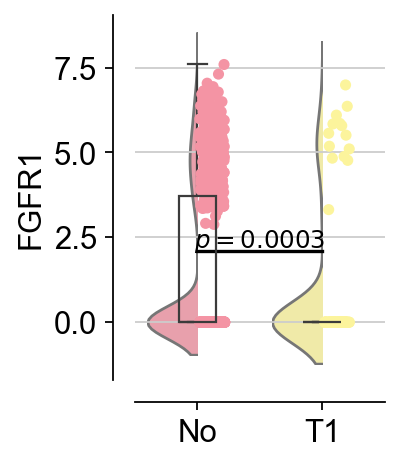

In [76]:
fig, ax = plt.subplots(1,1,figsize=(2,3))
ct='Gastric foveolar cell'
gene='FGFR1'
violin_box(adata_sub[adata_sub.obs['best_celltype']==ct],gene,
                 groupby='CancerStage',ax=ax,show=False,
            #fontsize=14
                )
ov.pl.add_palue(ax,line_x1=0,line_x2=1,line_y=2.1,
                  text_y=0.1,
                text='$p={}$'.format(round(deg_results_dict_inflow[ct].loc[gene,'qvalue'],4)),
                  fontsize=11,fontcolor='#000000',
                     horizontalalignment='center',)
plt.xlabel('')
plt.savefig(f'figures/signal/violin-signal-{gene}-{ct}-exp.png',dpi=300,bbox_inches='tight')


### outflow

In [77]:
adata_sub_o=ov.externel.flowsig.pl._plotting.subset_for_flow_type(adata,
                                                     var_type = 'all',
                                                     flowsig_expr_key = 'X_flow_cpdb',
                                                flowsig_network_key = 'flowsig_network_cpdb',)
adata_sub_o

AnnData object with n_obs × n_vars = 22357 × 172
    obs: 'sample_batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'patient', 'CancerType', 'mito_perc', 'cell_type_from_mulan_smoothing', 'CancerStage', 'gpt_celltype_0', 'Minor_celltype', 'cell_type_from_scMulan', 'log2umi', 'passing_ngenes', 'passing_mt', 'C_scANVI', 'gpt_celltype_2', 'best_celltype', 'cell_complexity', 'leiden', 'passing_nUMIs', 'cell_abbreviations', 'pct_counts_mt', 'detected_genes', 'smoothing_score', 'gpt_celltype_4', 'best_clusters', '_scvi_labels', 'celltype_gbi', 'n_genes', 'log2counts', 'doublet_score', 'gpt_celltype_1', 'celltype_gpt', 'Major_celltype', '_scvi_batch', 'nUMIs', 'gpt_celltype_3', 'predicted_doublet'
    var: 'Type', 'Downstream_TF', 'Interaction'

In [78]:
adata_sub_o=adata_sub_o[:,adata_sub_o.var['Type'].isin(['outflow'])]
adata_sub_o

View of AnnData object with n_obs × n_vars = 22357 × 76
    obs: 'sample_batch', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'patient', 'CancerType', 'mito_perc', 'cell_type_from_mulan_smoothing', 'CancerStage', 'gpt_celltype_0', 'Minor_celltype', 'cell_type_from_scMulan', 'log2umi', 'passing_ngenes', 'passing_mt', 'C_scANVI', 'gpt_celltype_2', 'best_celltype', 'cell_complexity', 'leiden', 'passing_nUMIs', 'cell_abbreviations', 'pct_counts_mt', 'detected_genes', 'smoothing_score', 'gpt_celltype_4', 'best_clusters', '_scvi_labels', 'celltype_gbi', 'n_genes', 'log2counts', 'doublet_score', 'gpt_celltype_1', 'celltype_gpt', 'Major_celltype', '_scvi_batch', 'nUMIs', 'gpt_celltype_3', 'predicted_doublet'
    var: 'Type', 'Downstream_TF', 'Interaction'

In [79]:
adata_sub_o.layers['normalized']=adata_sub_o.X.copy()

In [81]:
deg_results_dict_outflow=deg_clusters(adata=adata_sub_o,cluster_type='best_celltype',group_type='CancerStage',
                treatmentgroup='T1',controlgroup='No',layer='normalized')

 87%|████████▋ | 13/15 [00:00<00:00, 62.60it/s]

... Fold change threshold: 0.5
... Fold change threshold: 0.5
... Fold change threshold: 0.5
... Fold change threshold: 0.5
... Fold change threshold: 0.5
... Fold change threshold: 0.5
... Fold change threshold: 0.5
... Fold change threshold: 0.5
... Fold change threshold: 0.5
... Fold change threshold: 0.5
... Fold change threshold: 0.5
... Fold change threshold: 0.5
... Fold change threshold: 0.5


100%|██████████| 15/15 [00:00<00:00, 63.42it/s]

... Fold change threshold: 0.5


In [82]:
adata_sub_o.obsm=adata.obsm.copy()

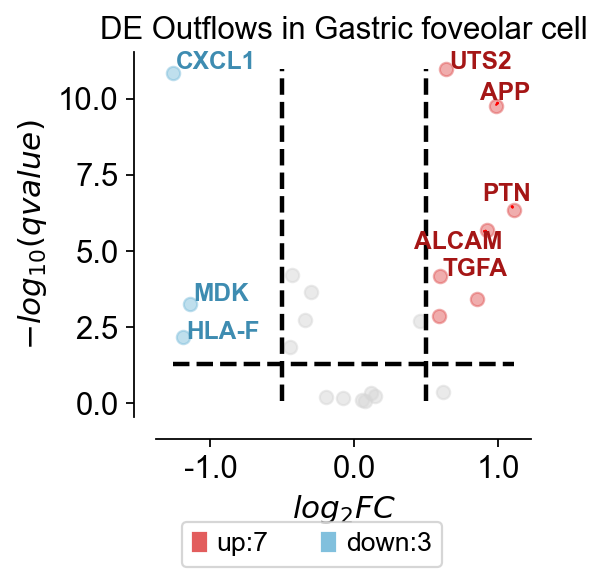

In [83]:
deg_cluster='Gastric foveolar cell'
ov.pl.volcano(deg_results_dict_outflow[deg_cluster],pval_name='qvalue',fc_name='log2FC',
                     pval_threshold=0.05,fc_max=0.5,fc_min=-0.5,
                      pval_max=100,FC_max=3,
                    figsize=(3,3),title=f'DE Outflows in {deg_cluster}',titlefont={'weight':'normal','size':14,},
                     up_color='#e25d5d',down_color=ov.pl.blue_color[2],normal_color='#d7d7d7',
                     up_fontcolor='#a51616',down_fontcolor=ov.pl.blue_color[3],normal_fontcolor='#d7d7d7',
                     legend_bbox=(0.8, -0.25),legend_ncol=2,legend_fontsize=12,
                     #plot_genes=['CMKLR1', 'ARHGEF10L', 'PRG4', 'OLR1', 'CRTAC1'],
                    plot_genes_num=10,plot_genes_fontsize=11,
                     ticks_fontsize=12,)
plt.savefig(f'figures/signal/gc_deg_outflow_{deg_cluster}.png',dpi=300,bbox_inches='tight')


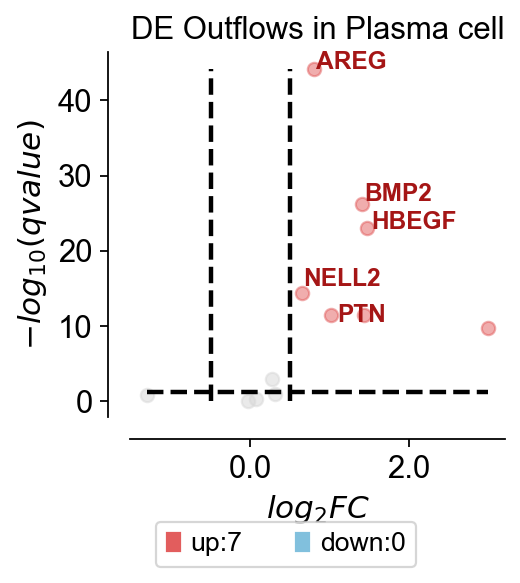

In [84]:
deg_cluster='Plasma cell'
ov.pl.volcano(deg_results_dict_outflow[deg_cluster],pval_name='qvalue',fc_name='log2FC',
                     pval_threshold=0.05,fc_max=0.5,fc_min=-0.5,
                      pval_max=100,FC_max=3,
                    figsize=(3,3),title=f'DE Outflows in {deg_cluster}',titlefont={'weight':'normal','size':14,},
                     up_color='#e25d5d',down_color=ov.pl.blue_color[2],normal_color='#d7d7d7',
                     up_fontcolor='#a51616',down_fontcolor=ov.pl.blue_color[3],normal_fontcolor='#d7d7d7',
                     legend_bbox=(0.8, -0.25),legend_ncol=2,legend_fontsize=12,
                     #plot_genes=['CMKLR1', 'ARHGEF10L', 'PRG4', 'OLR1', 'CRTAC1'],
                    plot_genes_num=10,plot_genes_fontsize=11,
                     ticks_fontsize=12,)
plt.savefig(f'figures/signal/gc_deg_outflow_{deg_cluster}.png',dpi=300,bbox_inches='tight')


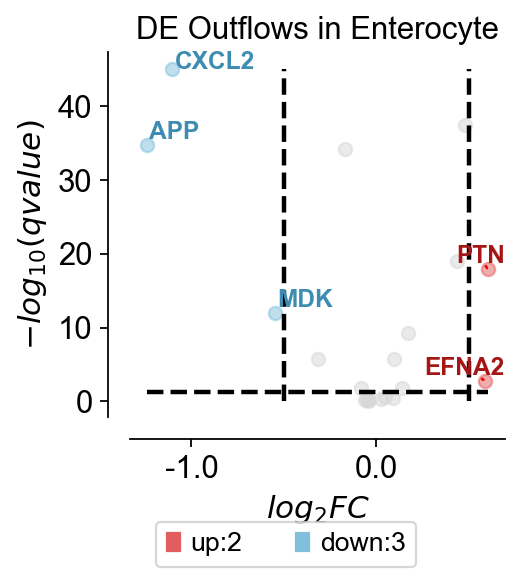

In [85]:
deg_cluster='Enterocyte'
ov.pl.volcano(deg_results_dict_outflow[deg_cluster],pval_name='qvalue',fc_name='log2FC',
                     pval_threshold=0.05,fc_max=0.5,fc_min=-0.5,
                      pval_max=100,FC_max=3,
                    figsize=(3,3),title=f'DE Outflows in {deg_cluster}',titlefont={'weight':'normal','size':14,},
                     up_color='#e25d5d',down_color=ov.pl.blue_color[2],normal_color='#d7d7d7',
                     up_fontcolor='#a51616',down_fontcolor=ov.pl.blue_color[3],normal_fontcolor='#d7d7d7',
                     legend_bbox=(0.8, -0.25),legend_ncol=2,legend_fontsize=12,
                     #plot_genes=['CMKLR1', 'ARHGEF10L', 'PRG4', 'OLR1', 'CRTAC1'],
                    plot_genes_num=10,plot_genes_fontsize=11,
                     ticks_fontsize=12,)
plt.savefig(f'figures/signal/gc_deg_outflow_{deg_cluster}.png',dpi=300,bbox_inches='tight')


... storing 'Type' as categorical
... storing 'Downstream_TF' as categorical


<AxesSubplot: title={'center': 'Group'}, xlabel='X_mde_scVI1', ylabel='X_mde_scVI2'>

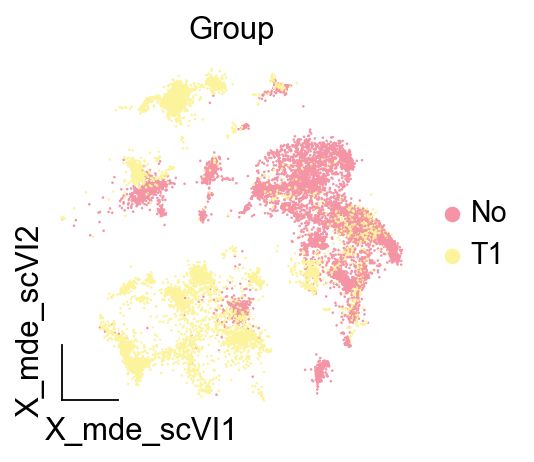

In [154]:
fb=ov.pl.ForbiddenCity()
fig, ax = plt.subplots(figsize=(3,3))
ov.utils.embedding(
    adata_sub_o,
    basis="X_mde_scVI",
    color=['CancerStage'],
    title='Group',
    frameon='small',
    #ncols=1,
    palette=[
             fb.get_color(name='杨妃')['color_html'].values[0],
             fb.get_color(name='黄白游')['color_html'].values[0],],
    #legend_loc='on data',
    #legend_fontsize=12,
    ax=ax,
    show=False
    #add_outline=True
    #legend_fontweight='normal'
)

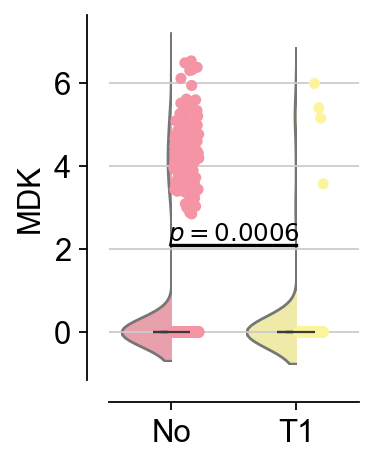

In [171]:
fig, ax = plt.subplots(1,1,figsize=(2,3))
ct='Gastric foveolar cell'
gene='MDK'
violin_box(adata_sub_o[adata_sub_o.obs['best_celltype']==ct],gene,
                 groupby='CancerStage',ax=ax,show=False,
            #fontsize=14
                )
ov.pl.add_palue(ax,line_x1=0,line_x2=1,line_y=2.1,
                  text_y=0.1,
                text='$p={}$'.format(round(deg_results_dict_outflow[ct].loc[gene,'qvalue'],4)),
                  fontsize=11,fontcolor='#000000',
                     horizontalalignment='center',)
plt.xlabel('')
plt.savefig(f'figures/signal/violin-signal-o-{gene}-{ct}-exp.png',dpi=300,bbox_inches='tight')


In [116]:
for p in pos:
    pos[p][1]*=2

[Text(-1.25, 0.12416107382550336, 'ERBB2'), Text(-1.4375, 0.12416107382550336, 'ADRB2'), Text(1.9375, 0.12416107382550336, 'AXL'), Text(-0.125, 0.12416107382550336, 'EPHB6'), Text(-1.03125, -0.12583892617449666, 'NELL2'), Text(-1.71875, -0.12583892617449666, 'PTN'), Text(-0.65625, -0.12583892617449666, 'HBEGF'), Text(-1.53125, -0.12583892617449666, 'CXCL8'), Text(-0.09375, -0.12583892617449666, 'CLCF1'), Text(-0.03125, -0.12583892617449666, 'AREG'), Text(0.78125, -0.12583892617449666, 'BMP2'), Text(0.34375, -0.0008389261744966443, 'GEM-3')]


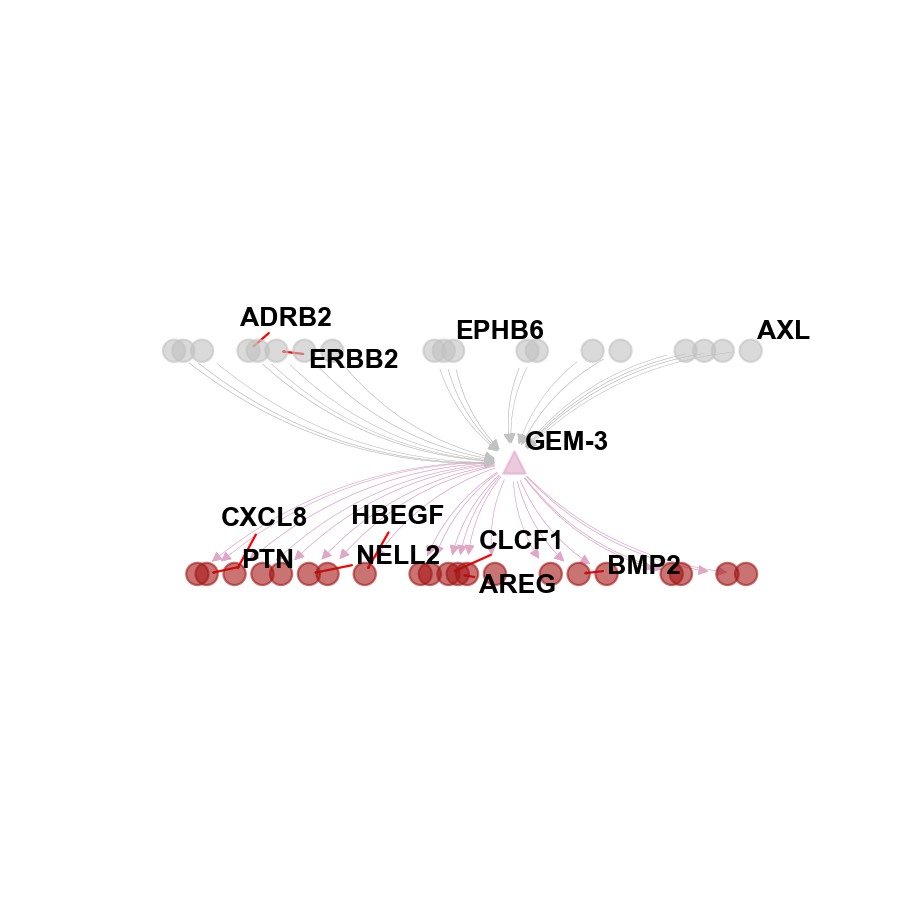

In [117]:
#fig, ax = plt.subplots(figsize=(8,8)) 
gem_li=['GEM-3']
sub_G=flow_network.subgraph(sender_li+receptor_li+gem_li).copy()
# 获取所有节点和边
all_nodes = set(sub_G.nodes())
all_edges = sub_G.edges()
# 找到没有连接边的节点
nodes_with_edges = set()
for edge in all_edges:
    nodes_with_edges.update(edge)
    
nodes_without_edges = all_nodes - nodes_with_edges

# 从图中删除这些节点
sub_G.remove_nodes_from(nodes_without_edges)

import bezier
from matplotlib.collections import LineCollection
from matplotlib.patches import FancyArrowPatch
import networkx as nx
deg_inflow=deg_results_dict_inflow['Plasma cell'].loc[deg_results_dict_inflow['Plasma cell']['sig']!='normal'].index.tolist()
deg_outflow=deg_results_dict_outflow['Plasma cell'].loc[deg_results_dict_outflow['Plasma cell']['sig']!='normal'].index.tolist()
deg_inflow=list(set(sub_G.nodes) & set(deg_inflow))
deg_outflow=list(set(sub_G.nodes) & set(deg_outflow))
ov.pl.plot_curve_network(sub_G,
                     G_type_dict=G_type_dict,
                     G_color_dict=G_color_dict,
                      pos_type=pos,
                      figsize=(6,6),
                     curve_awarg={'eps':4},
                      node_shape={'GEM':'^','Sender':'o','Receptor':'o'},
                   plot_node=deg_inflow+deg_outflow+gem_li
                     )
plt.box(False)
plt.savefig(f'figures/signal/gc_gem_flowsig_plasma.png',dpi=300,bbox_inches='tight')

[Text(1.0625, 0.12416107382550336, 'ADRA2A'), Text(-2.0, 0.12416107382550336, 'CNR1'), Text(-0.625, 0.12416107382550336, 'TNFRSF10B'), Text(1.1875, 0.12416107382550336, 'SORT1'), Text(-1.875, 0.12416107382550336, 'BSG'), Text(-1.625, 0.12416107382550336, 'CNR2'), Text(-1.5625, 0.12416107382550336, 'FGFR1'), Text(-1.5, 0.12416107382550336, 'IL6ST'), Text(1.625, 0.12416107382550336, 'PTGDR'), Text(-1.3125, 0.12416107382550336, 'NR1H3'), Text(-1.25, 0.12416107382550336, 'ERBB2'), Text(-0.1875, 0.12416107382550336, 'TNFRSF12A'), Text(0.5625, 0.12416107382550336, 'SSTR1'), Text(1.75, 0.12416107382550336, 'PDCD1'), Text(-0.0625, 0.12416107382550336, 'CXCR4'), Text(0.0625, 0.12416107382550336, 'RAMP3'), Text(0.8125, 0.12416107382550336, 'LTBR'), Text(0.9375, 0.12416107382550336, 'CD96'), Text(0.96875, -0.12583892617449666, 'TGFA'), Text(-1.09375, -0.12583892617449666, 'CD52'), Text(-1.84375, -0.12583892617449666, 'CXCL2'), Text(-0.78125, -0.12583892617449666, 'CXCL1'), Text(-1.71875, -0.12583

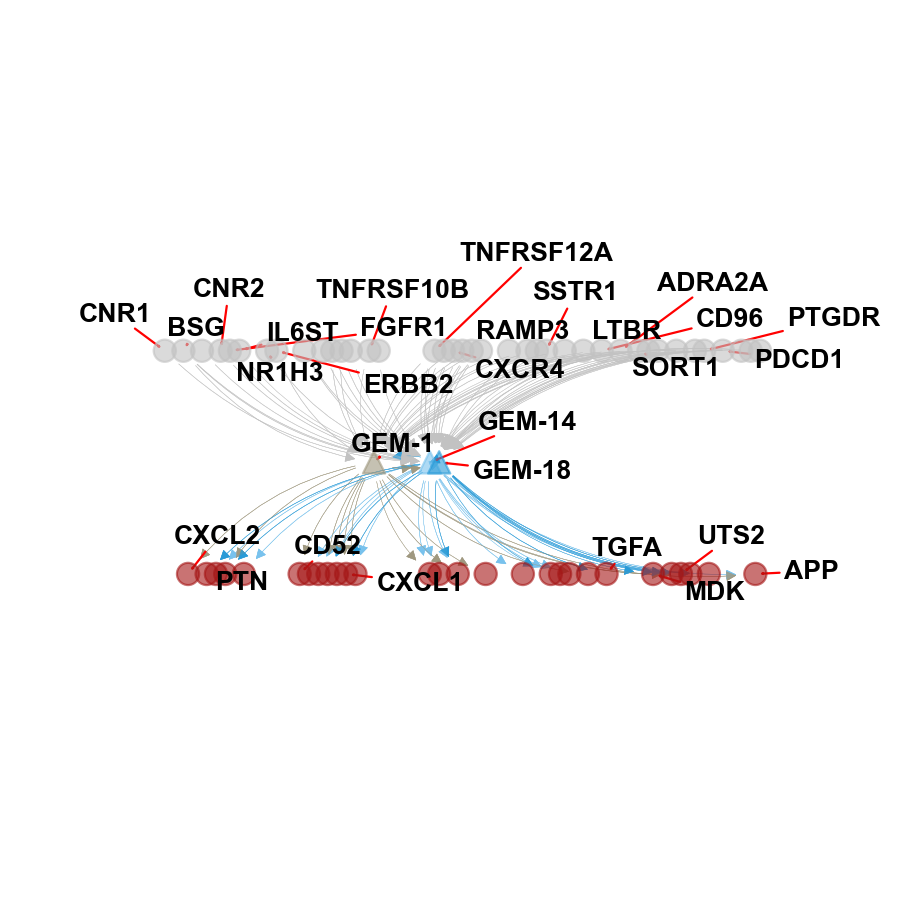

In [118]:
#fig, ax = plt.subplots(figsize=(8,8)) 
gem_li=['GEM-1','GEM-14','GEM-18']
sub_G=flow_network.subgraph(sender_li+receptor_li+gem_li).copy()
# 获取所有节点和边
all_nodes = set(sub_G.nodes())
all_edges = sub_G.edges()
# 找到没有连接边的节点
nodes_with_edges = set()
for edge in all_edges:
    nodes_with_edges.update(edge)
    
nodes_without_edges = all_nodes - nodes_with_edges

# 从图中删除这些节点
sub_G.remove_nodes_from(nodes_without_edges)

import bezier
from matplotlib.collections import LineCollection
from matplotlib.patches import FancyArrowPatch
import networkx as nx
deg_inflow=deg_results_dict_inflow['Enterocyte'].loc[deg_results_dict_inflow['Enterocyte']['sig']!='normal'].index.tolist()+\
deg_results_dict_inflow['Gastric foveolar cell'].loc[deg_results_dict_inflow['Gastric foveolar cell']['sig']!='normal'].index.tolist()
deg_outflow=deg_results_dict_outflow['Enterocyte'].loc[deg_results_dict_outflow['Enterocyte']['sig']!='normal'].index.tolist()+\
deg_results_dict_outflow['Gastric foveolar cell'].loc[deg_results_dict_outflow['Gastric foveolar cell']['sig']!='normal'].index.tolist()
deg_inflow=list(set(sub_G.nodes) & set(deg_inflow))
deg_outflow=list(set(sub_G.nodes) & set(deg_outflow))
ov.pl.plot_curve_network(sub_G,
                     G_type_dict=G_type_dict,
                     G_color_dict=G_color_dict,
                      pos_type=pos,
                      figsize=(6,6),
                     curve_awarg={'eps':4},
                      node_shape={'GEM':'^','Sender':'o','Receptor':'o'},
                   plot_node=deg_inflow+deg_outflow+gem_li
                     )
plt.box(False)
plt.savefig(f'figures/signal/gc_gem_flowsig_epi.png',dpi=300,bbox_inches='tight')

In [178]:
goal_gem='GEM-3'
gem_gene=ov.externel.flowsig.ul.get_top_gem_genes(adata=adata,
                                            gems=[goal_gem],
                                         n_genes=100,
                                         gene_type='all',
                                        method = 'pyliger',
                                        )
gem_gene

,Gene,GEM,Weight
0,MZB1,GEM-3,194.556369
1,TNFRSF17,GEM-3,178.968329
2,DERL3,GEM-3,176.902456
3,JCHAIN,GEM-3,158.686387
4,LINC02362,GEM-3,147.844626
...,...,...,...
95,SLC38A4-AS1,GEM-3,82.949753
96,SPINK2,GEM-3,82.857953
97,CREB3L2,GEM-3,82.456947
98,PNOC,GEM-3,82.256182


In [179]:
pathway_dict=ov.utils.geneset_prepare('../24_OA/genesets/GO_Biological_Process_2023.txt',organism='Human')

In [180]:
#deg_genes=dds.result.loc[dds.result['sig']!='normal'].index.tolist()
enr=ov.bulk.geneset_enrichment(gene_list=gem_gene['Gene'].tolist(),
                                pathways_dict=pathway_dict,
                                pvalue_type='auto',
                                #background=dds.result.index.tolist(),
                                organism='Human')
enr.to_csv(f'result/go_gem/gc_gem_go_{goal_gem}.csv')

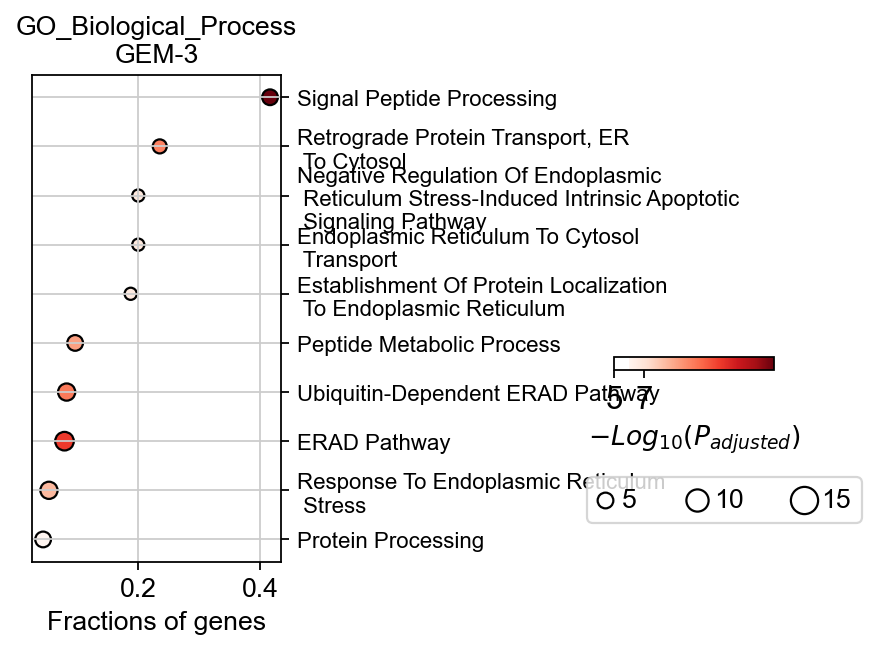

In [181]:
ov.bulk.geneset_plot(enr,figsize=(2,4),fig_title=f'GO_Biological_Process\n{goal_gem}',
                    cax_loc=[2, 0.45, 0.5, 0.02],
                    bbox_to_anchor_used=(-0.25, -13),node_diameter=10,
                     custom_ticks=[5,7],text_knock=4,
                    cmap='Reds')
plt.savefig(f'figures/signal/gc_gem_go_{goal_gem}.png',dpi=300,bbox_inches='tight')
